In [1]:
from astropy.table import Table
from common_functions import single_wavelet, plotter, reduce
import numpy as np
import matplotlib.colors as colors
import os
import pathlib
from pyasassn.client import SkyPatrolClient
import matplotlib.pyplot as plt

# This notebook is meant to demonstrate how one would make a single object wavelet transform given a specific ASAS-SN ID

In [2]:
os.chdir(pathlib.Path.cwd())
def set_rcparams():
    tab = Table.read('rcparams.txt', format='csv')
    for i in range(len(tab)):
        try:
            plt.rcParams[tab['key'][i]] = float(tab['val'][i])
        except ValueError:
            plt.rcParams[tab['key'][i]] = str(tab['val'][i])
    return
set_rcparams()

In [3]:
client = SkyPatrolClient()

Welcome to ASAS-SN Skypatrol!

Current Deployment Version: 0.6.19 (22 MAY 2025)
Please upgrade your client if not up to date.

We are reprocessing a number of lightcurves in database.
Once finished we should have more complete and higher quality photometry.
Thank you for your patience,
K. Hart (22 MAY 2025)




In [4]:
def pipeline(objid):
    lcs = client.query_list([objid], download=True)
    for lc in lcs.itercurves():
        savedlc = lc
    savedlc_fin = reduce(savedlc)
    wavelet = single_wavelet(savedlc_fin, savedlc_fin.data.flux)
    plotter(wavelet, True)
    return(savedlc_fin)

Pulled 1 of 1


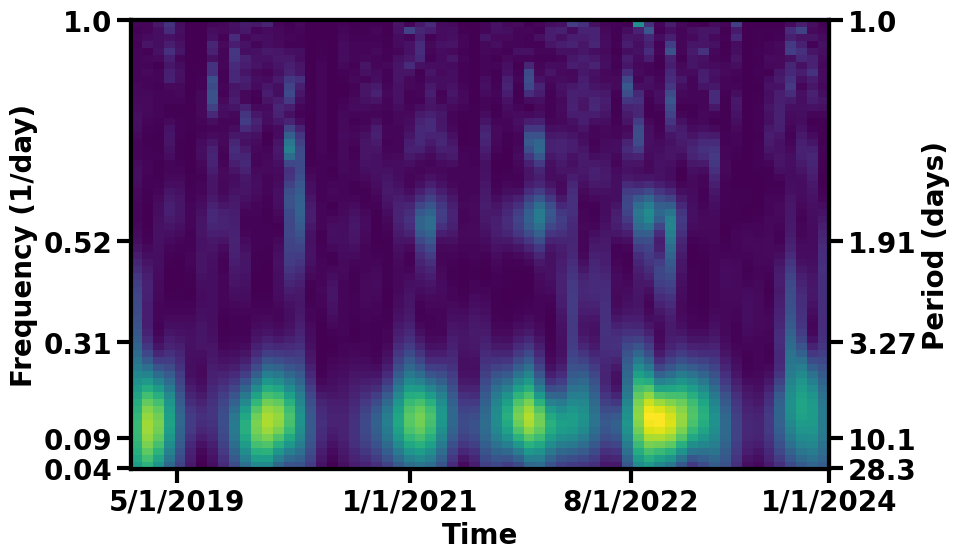

In [5]:
savedlc = pipeline(463856975202)